YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  6 of 6 completed
<ipython-input-1-af5a86495a63>:28: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


  Stock      Beta
3  NVDA  1.857983
0  PLTR  1.705141
4   TSM  1.324619
2  GOOG  0.878446
1  MSFT  0.783928

Explanation:
Beta measures a stock's volatility relative to the market index (here, NDX). A beta > 1 means the stock tends to be more volatile than NDX; a beta < 1 means it tends to be less volatile.
  Stock      Beta  Covariance (Stock, NDX)  Variance (NDX)  Manual Beta (1y)
0  NVDA  1.857983                 0.000475        0.000255          1.865475
1  PLTR  1.705141                 0.000436        0.000255          1.712017
2   TSM  1.324619                 0.000339        0.000255          1.329960
3  GOOG  0.878446                 0.000225        0.000255          0.881988
4  MSFT  0.783928                 0.000201        0.000255          0.787089


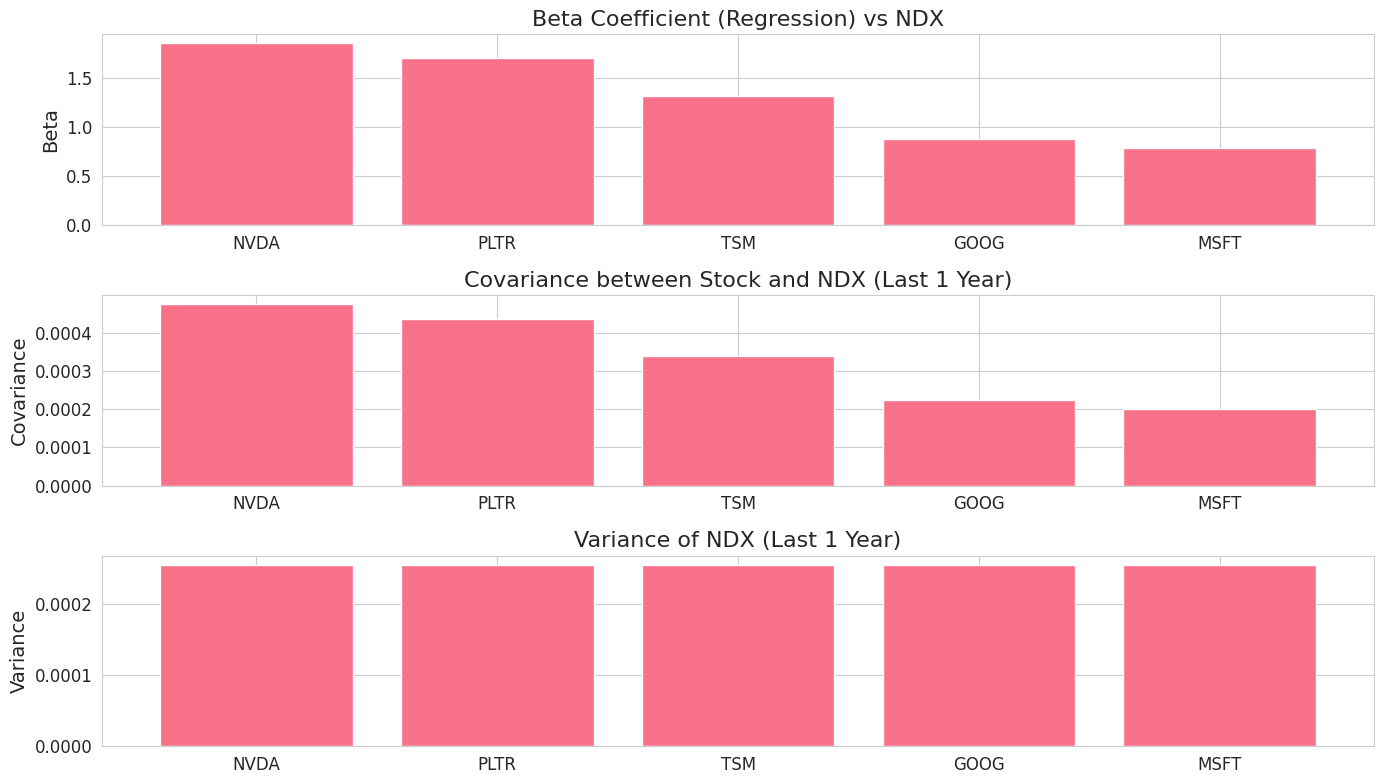

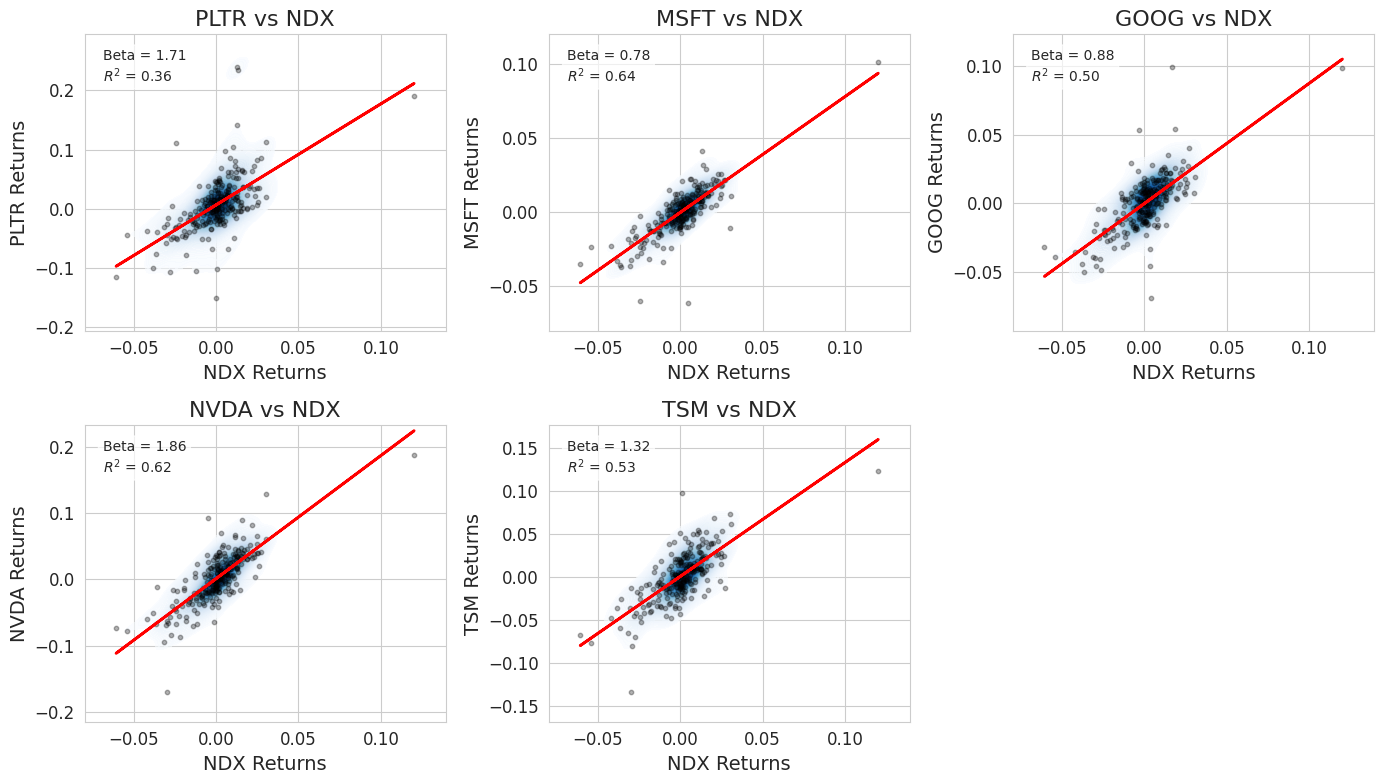

[*********************100%***********************]  6 of 6 completed
<ipython-input-1-af5a86495a63>:143: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_full = data_full.pct_change().dropna()


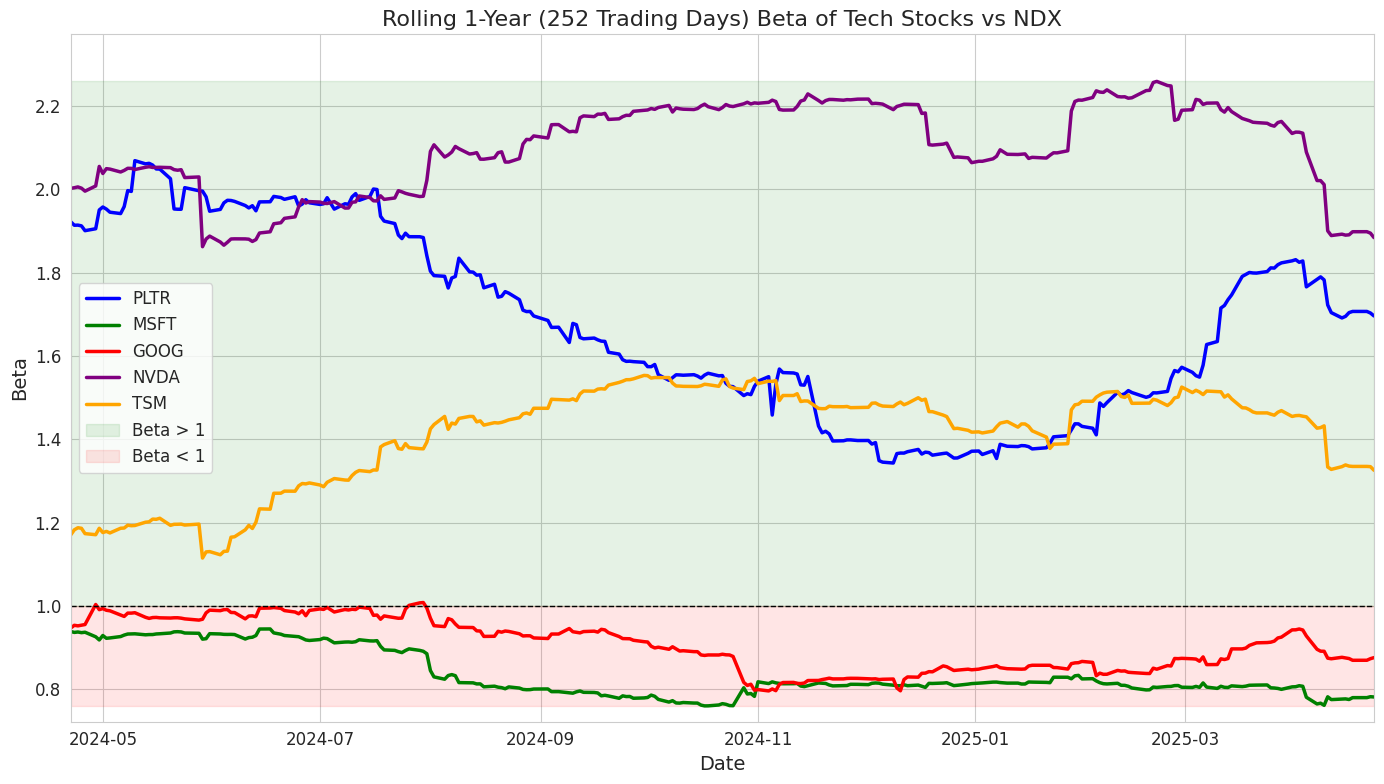

[*********************100%***********************]  6 of 6 completed
<ipython-input-1-af5a86495a63>:225: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_full = data_full.pct_change().dropna()
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date 

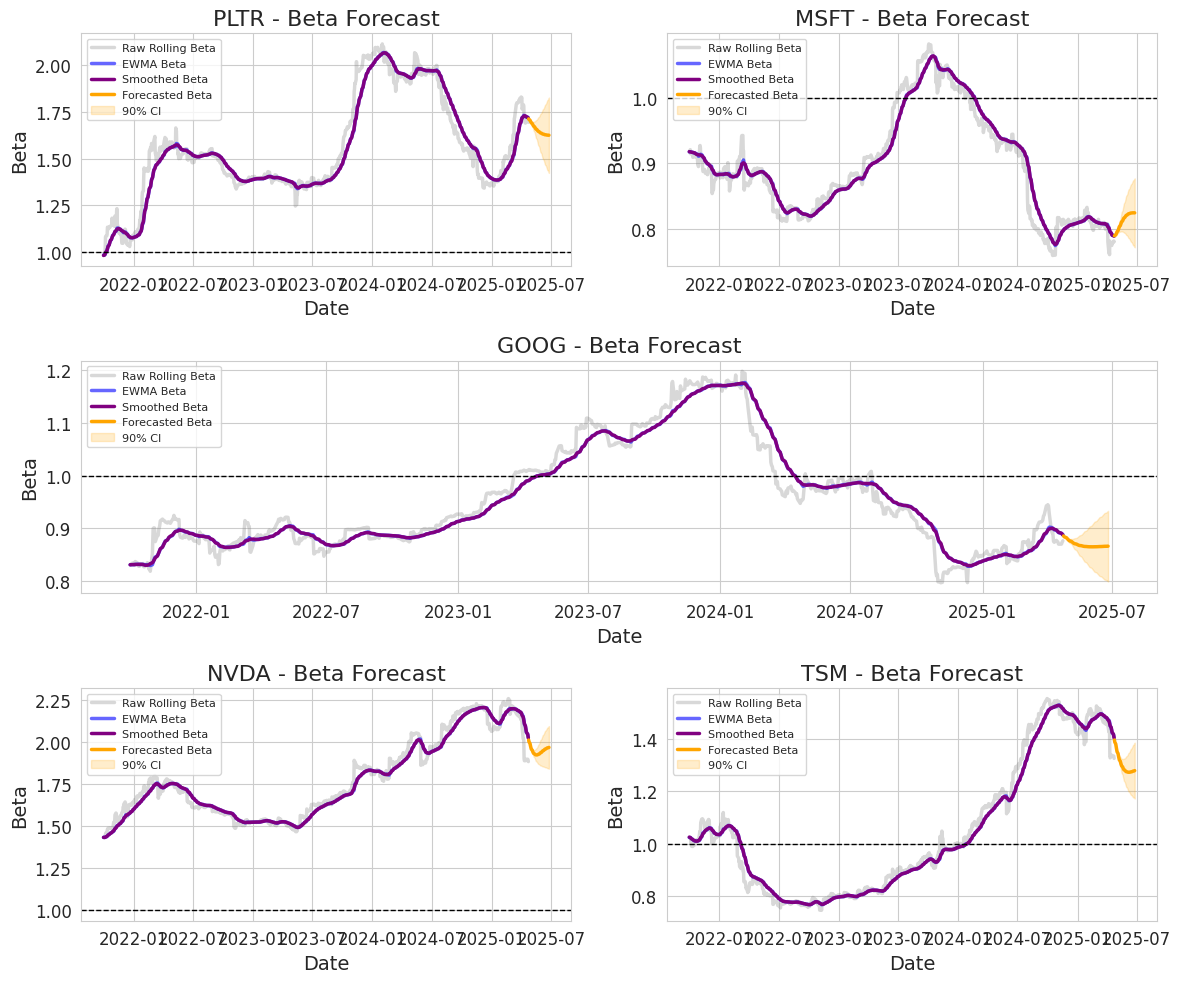

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette("husl")
rcParams.update({
    'figure.figsize': [12, 8],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5
})
rcParams.update({'figure.figsize': [4, 2]})

stocks = ['PLTR', 'MSFT', 'GOOG', 'NVDA', 'TSM']
index = 'NDX'

data = yf.download(stocks + [index], start='2024-04-24', end='2025-04-24', interval='1d')['Close']

returns = data.pct_change().dropna()

betas = {}

for stock in stocks:
    X = returns[index].values.reshape(-1, 1)
    y = returns[stock].values
    model = LinearRegression()
    model.fit(X, y)
    beta = model.coef_[0]
    betas[stock] = beta

beta_df = pd.DataFrame(list(betas.items()), columns=['Stock', 'Beta']).sort_values(by='Beta', ascending=False)

print(beta_df)

print("\nExplanation:")
print("Beta measures a stock's volatility relative to the market index (here, NDX). A beta > 1 means the stock tends to be more volatile than NDX; a beta < 1 means it tends to be less volatile.")

recent_returns = returns.loc[returns.index >= (returns.index.max() - pd.DateOffset(years=1))]

manual_beta_info = []

for stock in stocks:
    cov = np.cov(recent_returns[stock], recent_returns[index])[0, 1]
    var = np.var(recent_returns[index])

    beta_manual = cov / var

    manual_beta_info.append({
        'Stock': stock,
        'Covariance (Stock, NDX)': cov,
        'Variance (NDX)': var,
        'Manual Beta (1y)': beta_manual
    })

manual_beta_df = pd.DataFrame(manual_beta_info)

final_beta_df = beta_df.merge(manual_beta_df, on='Stock')

print(final_beta_df)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].bar(final_beta_df['Stock'], final_beta_df['Beta'])
axes[0].set_title('Beta Coefficient (Regression) vs NDX')
axes[0].set_ylabel('Beta')
axes[0].grid(True)

axes[1].bar(final_beta_df['Stock'], final_beta_df['Covariance (Stock, NDX)'])
axes[1].set_title('Covariance between Stock and NDX (Last 1 Year)')
axes[1].set_ylabel('Covariance')
axes[1].grid(True)

axes[2].bar(final_beta_df['Stock'], final_beta_df['Variance (NDX)'])
axes[2].set_title('Variance of NDX (Last 1 Year)')
axes[2].set_ylabel('Variance')
axes[2].grid(True)

plt.tight_layout()
plt.show()

from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, stock in enumerate(stocks):
    ax = axs[i]

    x = returns[index]
    y = returns[stock]

    sns.kdeplot(
        x=x,
        y=y,
        fill=True,
        cmap="Blues",
        thresh=0.05,
        levels=100,
        ax=ax,
        alpha=0.6
    )
    ax.scatter(x, y, s=10, alpha=0.3, color='black')  # Also plot raw points lightly

    model = LinearRegression()
    X = x.values.reshape(-1, 1)
    y_vals = y.values
    model.fit(X, y_vals)
    predicted = model.predict(X)

    r_squared = r2_score(y_vals, predicted)
    beta_value = model.coef_[0]

    ax.plot(x, predicted, color='red', linewidth=2)

    ax.set_title(f'{stock} vs NDX')
    ax.set_xlabel('NDX Returns')
    ax.set_ylabel(f'{stock} Returns')
    ax.grid(True)

    textstr = f'Beta = {beta_value:.2f}\n$R^2$ = {r_squared:.2f}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.7)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

if len(stocks) < len(axs):
    for j in range(len(stocks), len(axs)):
        fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

data_full = yf.download(stocks + [index], start='2019-04-24', end='2025-04-24', interval='1d', auto_adjust=False)['Close']
returns_full = data_full.pct_change().dropna()

rolling_window = 252
plt.figure(figsize=(14, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange']
all_dates = []
all_betas = []

for idx, stock in enumerate(stocks):
    rolling_betas = []
    rolling_dates = []

    for i in range(rolling_window, len(returns_full)):
        x_window = returns_full[index].iloc[i-rolling_window:i]
        y_window = returns_full[stock].iloc[i-rolling_window:i]

        if len(x_window) == rolling_window and len(y_window) == rolling_window:
            model = LinearRegression()
            model.fit(x_window.values.reshape(-1, 1), y_window.values)
            beta = model.coef_[0]
            rolling_betas.append(beta)
            rolling_dates.append(returns_full.index[i])

    if rolling_betas:
        rolling_betas = rolling_betas[-252:]
        rolling_dates = rolling_dates[-252:]

        plt.plot(rolling_dates, rolling_betas, label=stock, color=colors[idx])
        all_dates.extend(rolling_dates)
        all_betas.extend(rolling_betas)

plt.title('Rolling 1-Year (252 Trading Days) Beta of Tech Stocks vs NDX', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Beta', fontsize=14)
plt.axhline(1, color='black', linestyle='--', linewidth=1)
plt.grid(True)

if all_dates and all_betas:
    xmin = min(all_dates)
    xmax = max(all_dates)
    ymin = min(all_betas)
    ymax = max(all_betas)
    plt.fill_between([xmin, xmax], 1, ymax, color='green', alpha=0.1, label='Beta > 1')
    plt.fill_between([xmin, xmax], ymin, 1, color='red', alpha=0.1, label='Beta < 1')
    plt.xlim([xmin, xmax])
    plt.ylim([ymin * 0.95, ymax * 1.05])

plt.legend()
plt.tight_layout()
plt.show()

from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
import yfinance as yf
from matplotlib.gridspec import GridSpec


sns.set_style('whitegrid')
sns.set_palette("husl")
plt.rcParams.update({
    'figure.figsize': [12, 8],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5
})

stocks = ['PLTR', 'MSFT', 'GOOG', 'NVDA', 'TSM']
index = 'NDX'
rolling_window = 252
forecast_days = 45

data_full = yf.download(stocks + [index], start='2019-04-24', end='2025-04-24', interval='1d', auto_adjust=False)['Close']
returns_full = data_full.pct_change().dropna()

fig = plt.figure(figsize=(12, 10))
gs = GridSpec(3, 2, figure=fig)
axs = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, :]),
    fig.add_subplot(gs[2, 0]),
    fig.add_subplot(gs[2, 1])
]

for idx, stock in enumerate(stocks):
    rolling_betas = []
    rolling_dates = []
    for i in range(rolling_window, len(returns_full)):
        x_window = returns_full[index].iloc[i - rolling_window:i]
        y_window = returns_full[stock].iloc[i - rolling_window:i]
        model = LinearRegression().fit(x_window.values.reshape(-1, 1), y_window.values)
        rolling_betas.append(model.coef_[0])
        rolling_dates.append(returns_full.index[i])

    beta_series = pd.Series(rolling_betas, index=rolling_dates)

    ewma_beta = beta_series.ewm(span=30, adjust=False).mean()

    smoothed_beta = savgol_filter(ewma_beta, window_length=21, polyorder=3)
    smoothed_beta_series = pd.Series(smoothed_beta, index=ewma_beta.index)

    arima_model = ARIMA(smoothed_beta_series, order=(2, 1, 2))
    arima_result = arima_model.fit()

    forecast = arima_result.get_forecast(steps=forecast_days)
    pred_beta = forecast.predicted_mean
    conf_int = forecast.conf_int(alpha=0.1)

    last_date = smoothed_beta_series.index[-1]
    forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)
    pred_beta.index = forecast_dates
    conf_int.index = forecast_dates

    ax = axs[idx]
    ax.plot(beta_series, label='Raw Rolling Beta', color='gray', alpha=0.3)
    ax.plot(ewma_beta, label='EWMA Beta', color='blue', alpha=0.6)
    ax.plot(smoothed_beta_series, label='Smoothed Beta', color='purple')
    ax.plot(pred_beta, label='Forecasted Beta', color='orange')
    ax.fill_between(forecast_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='orange', alpha=0.2, label='90% CI')

    ax.set_title(f'{stock} - Beta Forecast')
    ax.axhline(1, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Date')
    ax.set_ylabel('Beta')
    ax.grid(True)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()
